In [1]:
using FCSFitting

In [2]:
using DelimitedFiles

filepath = raw"fcs_sample.txt"
data = read_fcs(filepath; start_idx = 20, end_idx = 300);

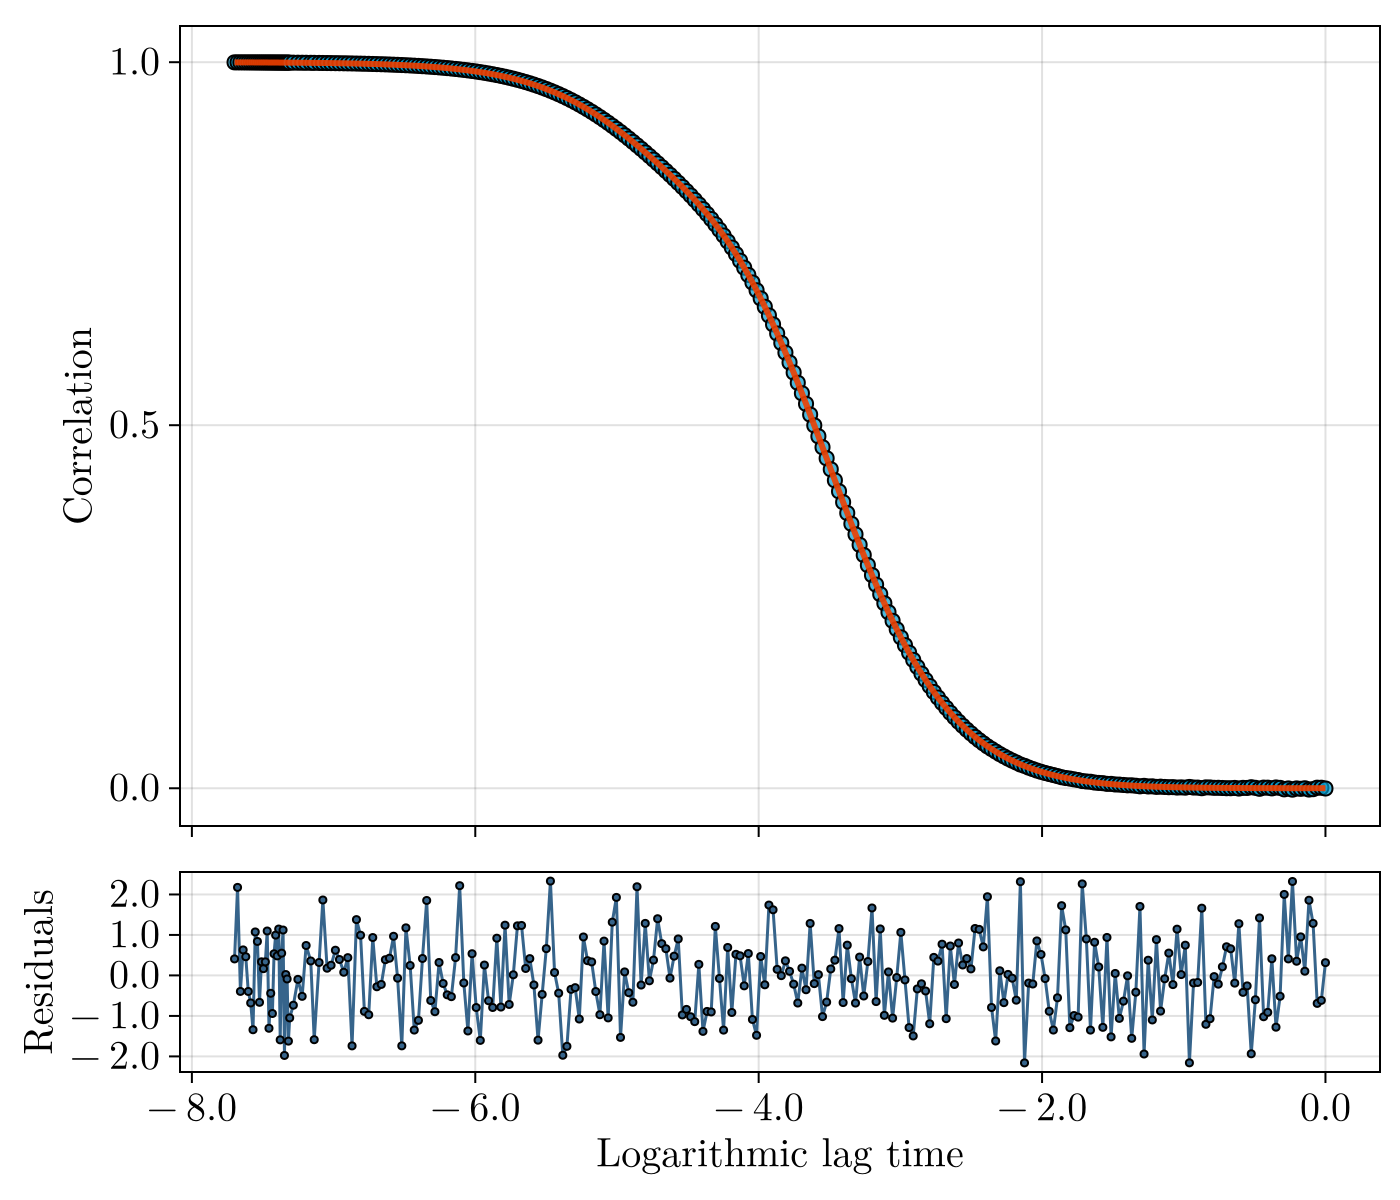

In [3]:
using CairoMakie
using LaTeXStrings

diffusivity=5e-11; offset=0.0
spec = FCSModelSpec(dim = FCSFitting.d3, anom = FCSFitting.none, offset = offset, diffusivity = diffusivity)

initial_parameters = [1.0, 5, 2e-7, 1e-7, 0.1]
lower_bounds = [0.9, 1, 1e-8, 1e-8, 0.0]
upper_bounds = [1.1, 20, 1e-6, 1e-4, 0.5]
fit = fcs_fit(spec, data.channels[1], initial_parameters; lower = lower_bounds, upper = upper_bounds)
fig, _ = fcs_plot(fit, data.channels[1]; fontsize=20)
fig

In [6]:
using PrettyTables

fcs_table(fit; units=["", "", "n", "μ", ""], gof_metric=aic)

Parameters 
 Values 
 Std. Dev. 
 
 
 
 
 Current amplitude 
 1 
 2.828e-7 
 
 
 Structure factor 
 8.015 
 0.01096 
 
 
 Beam width [nm] 
 250 
 0.007683 
 
 
 Dynamic lifetime 1 [μs] 
 10 
 7.954e-4 
 
 
 Dynamic population fraction 1 
 0.1 
 6.554e-6 
 
 
 
 
 aic = 2273.53

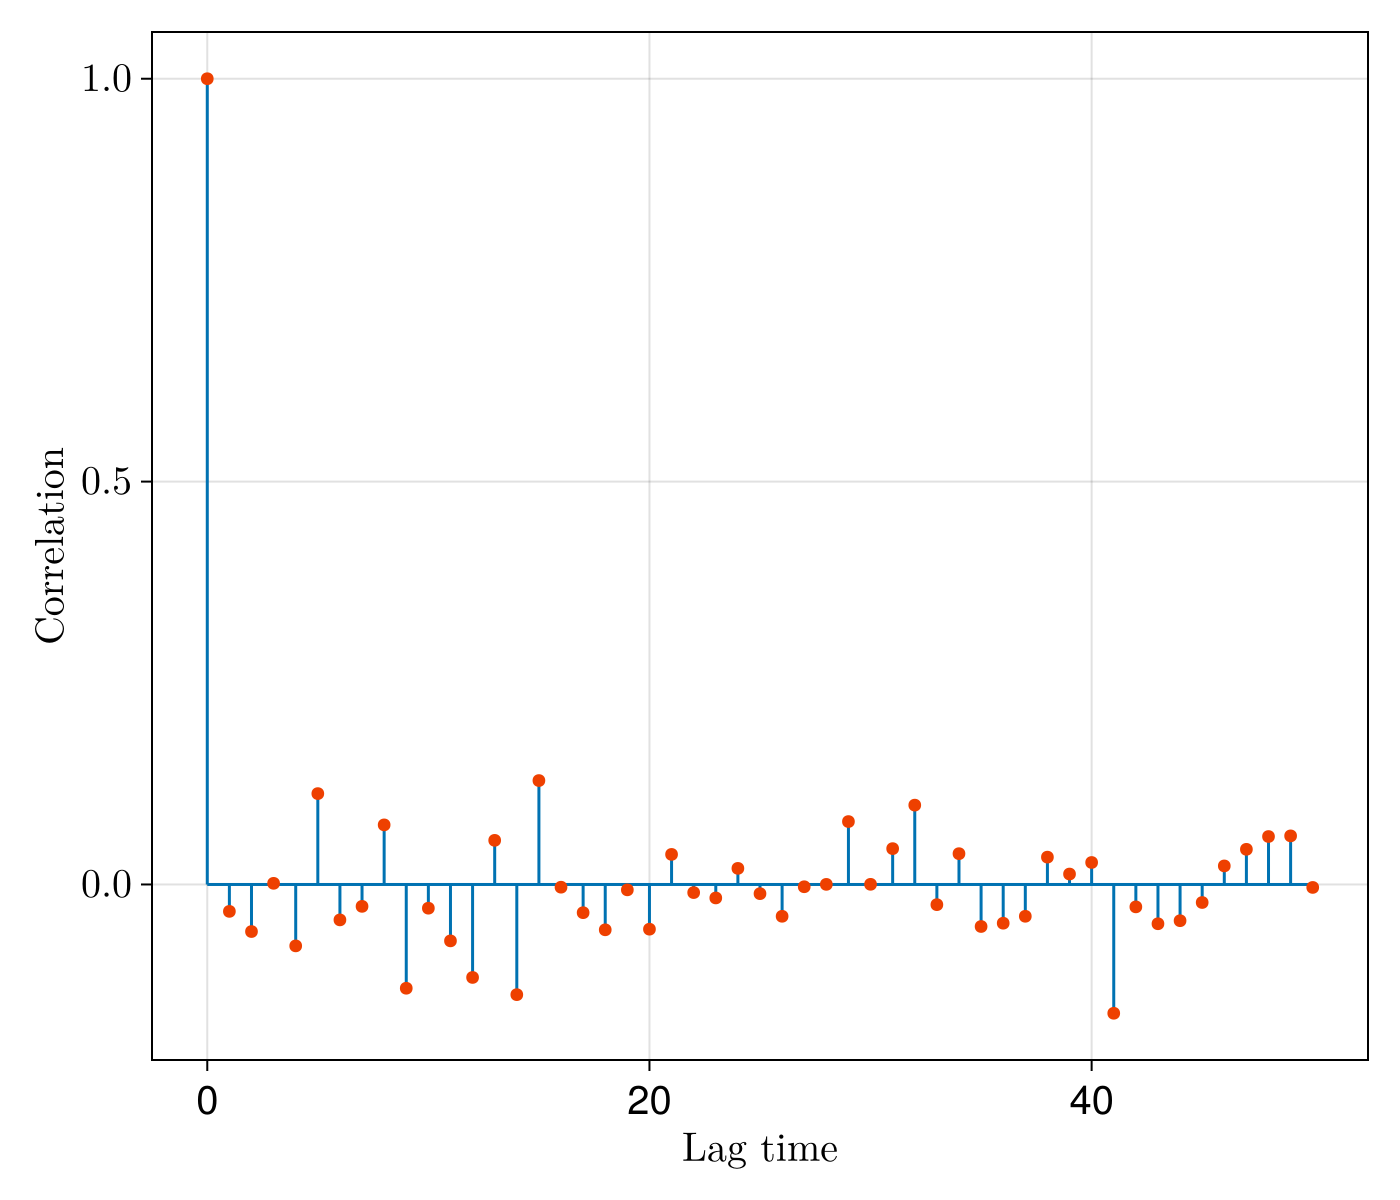

In [5]:
fig, ρ = resid_acf_plot(fit; maxlag=50)
fig